## Hepatocyte

In [1]:
import pandas as pd
import numpy as np

# 1. 결과 읽기
df = pd.read_csv('Hepatocytes_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

# 2. 원래 Seed 리스트 읽기
with open('../seed/Hepatocytes_Module1_Cirrhosis_Up_434genes.txt', 'r') as f:
    seed_genes = set([line.strip().split()[0] for line in f if line.strip()])

# 3. Seed 유무 표시
df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')

# 4. Empirical p-value 계산 (rank-based)
# 높은 점수일수록 유의 → p = (rank from top) / total
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

# 5. 저장
df.to_csv('Hepatocytes_NP_Final_Results_top.csv', index=False)

# 결과 요약 출력
print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 402 / 434

Top 20 Genes:
    Gene  NP_Score is_Seed  Rank  P_value
    TP53  0.001783      No     1 0.000062
   USP32  0.001309     Yes     2 0.000123
  ZNF407  0.001309     Yes     3 0.000185
ARHGAP15  0.001309     Yes     4 0.000247
 FAM172A  0.001309     Yes     5 0.000309
  CTNNB1  0.001224      No     6 0.000370
    EGFR  0.001213      No     7 0.000432
 PLAC8L1  0.001178      No     8 0.000494
  ZNF236  0.001178      No     9 0.000556
   GTDC1  0.001178      No    10 0.000617
   CDC42  0.001087      No    11 0.000679
  RPS27A  0.001027      No    12 0.000741
   H3C13  0.001004      No    13 0.000802
   H3C12  0.000978      No    14 0.000864
   EP300  0.000972      No    15 0.000926
    AKT1  0.000947      No    16 0.000988
     UBC  0.000927      No    17 0.001049
   HDAC1  0.000916      No    18 0.001111
   UBA52  0.000913      No    19 0.001173
     SRC  0.000911      No    20 0.001234


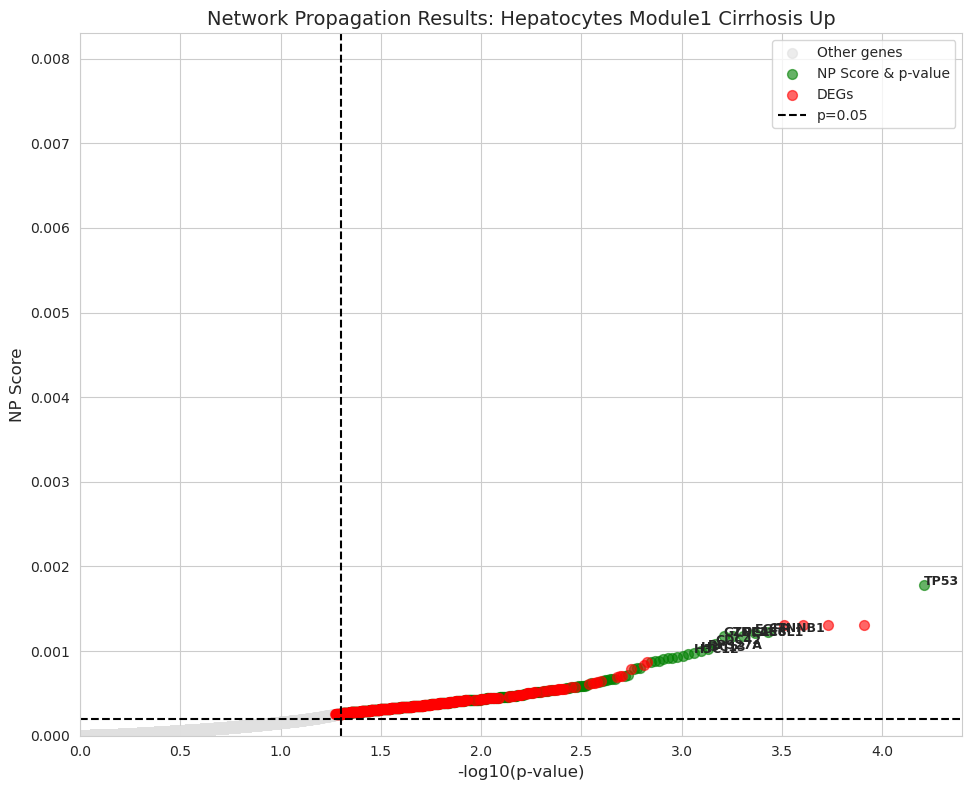

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000195
NP Score & p-value genes: 431

=== Novel Candidate Genes (431) ===
     Gene  NP_Score  P_value  Rank
     TP53  0.001783 0.000062     1
   CTNNB1  0.001224 0.000370     6
     EGFR  0.001213 0.000432     7
  PLAC8L1  0.001178 0.000494     8
   ZNF236  0.001178 0.000556     9
    GTDC1  0.001178 0.000617    10
    CDC42  0.001087 0.000679    11
   RPS27A  0.001027 0.000741    12
    H3C13  0.001004 0.000802    13
    H3C12  0.000978 0.000864    14
    EP300  0.000972 0.000926    15
     AKT1  0.000947 0.000988    16
      UBC  0.000927 0.001049    17
    HDAC1  0.000916 0.001111    18
    UBA52  0.000913 0.001173    19
      SRC  0.000911 0.001234    20
     H4C6  0.000884 0.001296    21
      MYC  0.000883 0.001358    22
     ACTB  0.000876 0.001420    23
    H3-3B  0.000802 0.001605    26
     RHOA  0.000797 0.001667    27
    BRCA1  0.000787 0.001728    28
     GRB2  0.000713 0.001852    30
 HSP90AA1  0.000709 0.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Hepatocytes_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

# Score cutoff: non-seed 상위 5%
non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

# 3-category 분류
color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: Hepatocytes Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")

## T_Cells

In [3]:
df = pd.read_csv('T_Cells_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

with open('../seed/T_Cells_Module1_Cirrhosis_Up_313genes.txt', 'r') as f:
    seed_genes = set([line.strip() for line in f if line.strip()])

df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

df.to_csv('T_Cells_NP_Final_Results_top.csv', index=False)

print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 285 / 313

Top 20 Genes:
    Gene  NP_Score is_Seed  Rank  P_value
    TP53  0.001850      No     1 0.000062
ARHGAP15  0.001847     Yes     2 0.000123
  ZNF407  0.001847     Yes     3 0.000185
 FAM172A  0.001847     Yes     4 0.000247
   GTDC1  0.001662      No     5 0.000309
  ZNF236  0.001662      No     6 0.000370
 PLAC8L1  0.001662      No     7 0.000432
  CTNNB1  0.001571     Yes     8 0.000494
    EGFR  0.001078      No     9 0.000556
   HDAC1  0.001057      No    10 0.000617
   EP300  0.001057      No    11 0.000679
   H3C13  0.001045      No    12 0.000741
  RPS27A  0.001035      No    13 0.000802
   H3C12  0.001000      No    14 0.000864
     MYC  0.000986      No    15 0.000926
    H4C6  0.000934      No    16 0.000988
     UBC  0.000932      No    17 0.001049
   UBA52  0.000927      No    18 0.001111
    AKT1  0.000903      No    19 0.001173
    ACTB  0.000858      No    20 0.001234


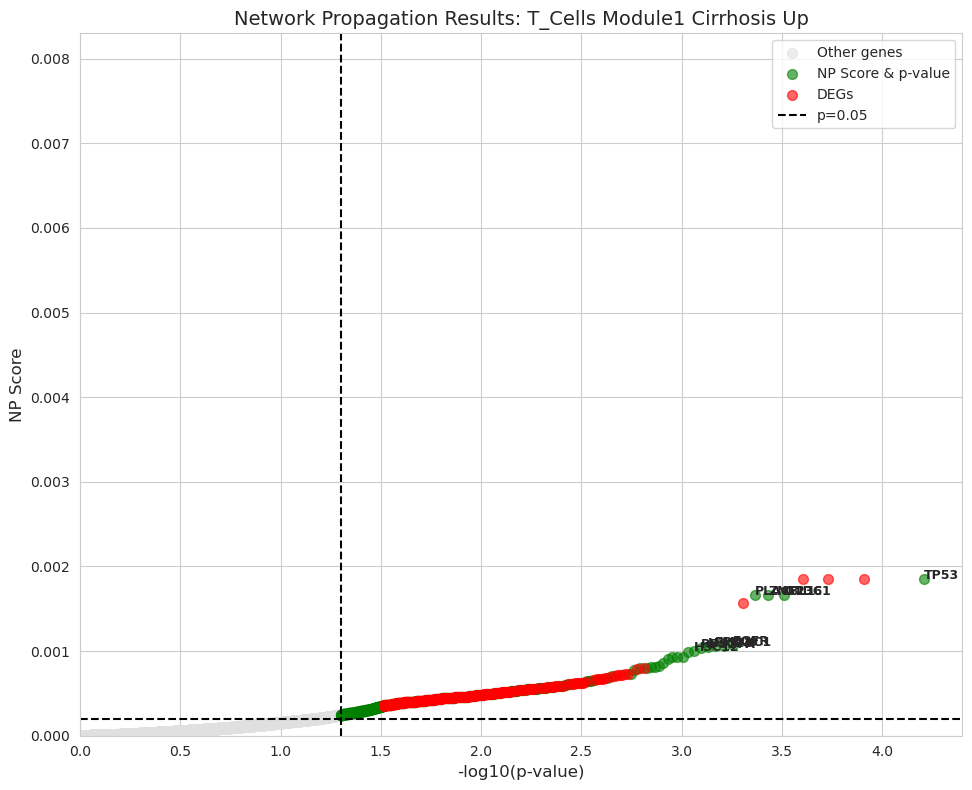

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000201
NP Score & p-value genes: 525

=== Novel Candidate Genes (525) ===
     Gene  NP_Score  P_value  Rank
     TP53  0.001850 0.000062     1
    GTDC1  0.001662 0.000309     5
   ZNF236  0.001662 0.000370     6
  PLAC8L1  0.001662 0.000432     7
     EGFR  0.001078 0.000556     9
    HDAC1  0.001057 0.000617    10
    EP300  0.001057 0.000679    11
    H3C13  0.001045 0.000741    12
   RPS27A  0.001035 0.000802    13
    H3C12  0.001000 0.000864    14
      MYC  0.000986 0.000926    15
     H4C6  0.000934 0.000988    16
      UBC  0.000932 0.001049    17
    UBA52  0.000927 0.001111    18
     AKT1  0.000903 0.001173    19
     ACTB  0.000858 0.001234    20
      SRC  0.000828 0.001296    21
    CDC42  0.000817 0.001358    22
    H3-3B  0.000811 0.001420    23
     RHOA  0.000806 0.001481    24
    BRCA1  0.000798 0.001605    26
 HSP90AA1  0.000777 0.001728    28
    HDAC2  0.000730 0.001790    29
     H3-4  0.000700 0.

In [4]:
df = pd.read_csv('T_Cells_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: T_Cells Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")

## Mesenchymal

In [5]:
df = pd.read_csv('Mesenchymal_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

with open('../seed/Mesenchymal_Module1_Cirrhosis_Up_391genes.txt', 'r') as f:
    seed_genes = set([line.strip() for line in f if line.strip()])

df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

df.to_csv('Mesenchymal_NP_Final_Results_top.csv', index=False)

print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 355 / 391

Top 20 Genes:
  Gene  NP_Score is_Seed  Rank  P_value
  TP53  0.001728      No     1 0.000062
  EGFR  0.001723     Yes     2 0.000123
ZNF407  0.001482     Yes     3 0.000185
 USP32  0.001482     Yes     4 0.000247
CTNNB1  0.001465      No     5 0.000309
ZNF236  0.001334      No     6 0.000370
 CDC42  0.001180      No     7 0.000432
   SRC  0.001006      No     8 0.000494
RPS27A  0.000985      No     9 0.000556
 EP300  0.000976      No    10 0.000617
 HDAC1  0.000961      No    11 0.000679
  AKT1  0.000960      No    12 0.000741
  RHOA  0.000927      No    13 0.000802
  ACTB  0.000898      No    14 0.000864
   MYC  0.000890      No    15 0.000926
   UBC  0.000889      No    16 0.000988
  PTEN  0.000884     Yes    17 0.001049
 UBA52  0.000868      No    18 0.001111
 H3C13  0.000808      No    19 0.001173
 MAPK1  0.000801     Yes    20 0.001234


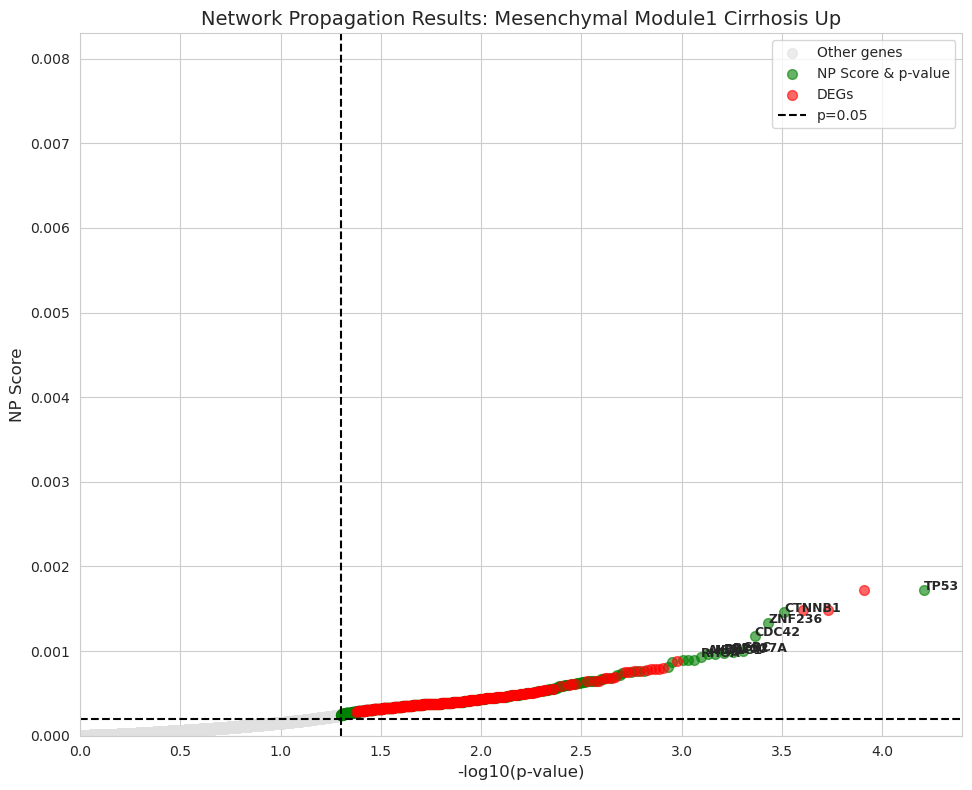

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000193
NP Score & p-value genes: 455

=== Novel Candidate Genes (455) ===
     Gene  NP_Score  P_value  Rank
     TP53  0.001728 0.000062     1
   CTNNB1  0.001465 0.000309     5
   ZNF236  0.001334 0.000370     6
    CDC42  0.001180 0.000432     7
      SRC  0.001006 0.000494     8
   RPS27A  0.000985 0.000556     9
    EP300  0.000976 0.000617    10
    HDAC1  0.000961 0.000679    11
     AKT1  0.000960 0.000741    12
     RHOA  0.000927 0.000802    13
     ACTB  0.000898 0.000864    14
      MYC  0.000890 0.000926    15
      UBC  0.000889 0.000988    16
    UBA52  0.000868 0.001111    18
    H3C13  0.000808 0.001173    19
     H4C6  0.000771 0.001543    25
 HSP90AA1  0.000764 0.001667    27
    H3C12  0.000759 0.001790    29
    BRCA1  0.000740 0.001975    32
     GRB2  0.000721 0.002037    33
    CALM3  0.000719 0.002099    34
      TNF  0.000684 0.002284    37
   TBC1D3  0.000667 0.002469    40
  TBC1D3B  0.000667 0.

In [6]:
df = pd.read_csv('Mesenchymal_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: Mesenchymal Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")

## Macrophages

In [7]:
df = pd.read_csv('Macrophages_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

with open('../seed/Macrophages_Module1_Cirrhosis_Up_133genes.txt', 'r') as f:
    seed_genes = set([line.strip() for line in f if line.strip()])

df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

df.to_csv('Macrophages_NP_Final_Results_top.csv', index=False)

print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 120 / 133

Top 20 Genes:
   Gene  NP_Score is_Seed  Rank  P_value
 ZNF407  0.004386     Yes     1 0.000062
 ZNF236  0.003948      No     2 0.000123
 CTNNB1  0.001976     Yes     3 0.000185
   TP53  0.001637      No     4 0.000247
   MT1E  0.001607     Yes     5 0.000309
    ALB  0.001482     Yes     6 0.000370
B4GALT1  0.001478     Yes     7 0.000432
    APP  0.001459     Yes     8 0.000494
  SNX13  0.001445     Yes     9 0.000556
 MAN2A1  0.001344     Yes    10 0.000617
  NFKB1  0.001277     Yes    11 0.000679
   MT2A  0.001275     Yes    12 0.000741
   EGFR  0.001211      No    13 0.000802
  BBOX1  0.001176      No    14 0.000864
  APOA1  0.001166     Yes    15 0.000926
 CHST11  0.001164     Yes    16 0.000988
     C3  0.001141     Yes    17 0.001049
   PRKN  0.001129     Yes    18 0.001111
 FBXW11  0.001126     Yes    19 0.001173
 ZNF644  0.001122     Yes    20 0.001234


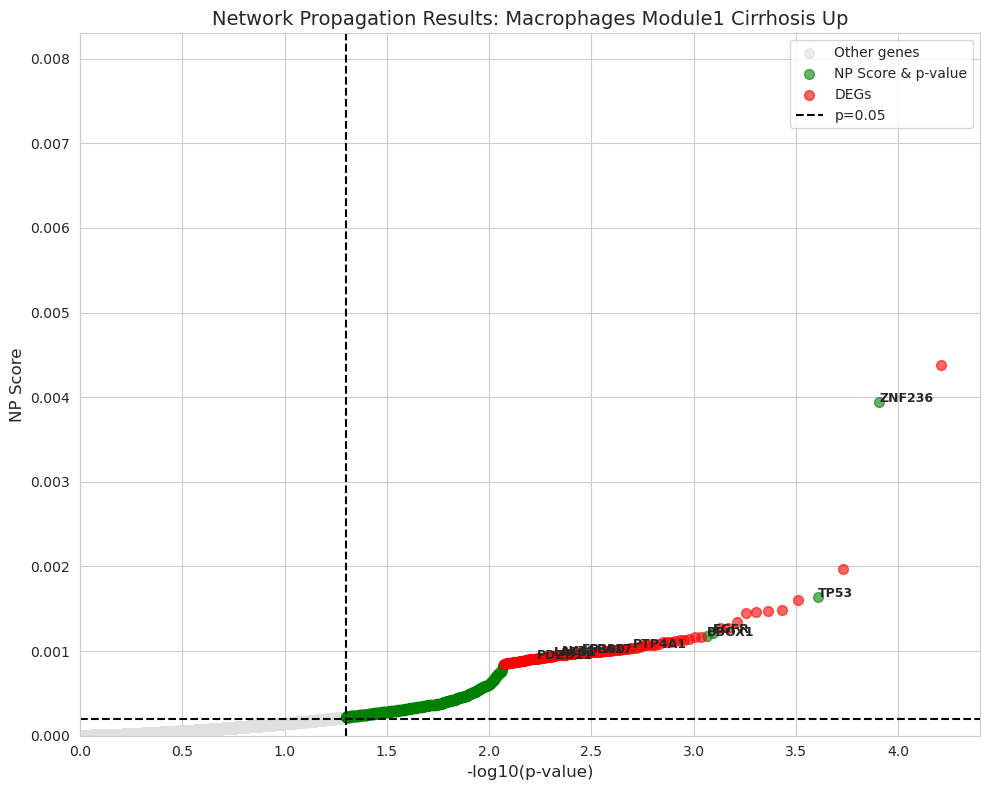

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000203
NP Score & p-value genes: 690

=== Novel Candidate Genes (690) ===
          Gene  NP_Score  P_value  Rank
        ZNF236  0.003948 0.000123     2
          TP53  0.001637 0.000247     4
          EGFR  0.001211 0.000802    13
         BBOX1  0.001176 0.000864    14
        PTP4A1  0.001034 0.001975    32
         SPA17  0.000983 0.003271    53
         EP300  0.000978 0.003518    57
          AKT1  0.000952 0.004506    73
         LATS1  0.000943 0.004815    78
        PDZD11  0.000912 0.005864    95
         HDAC1  0.000908 0.005987    97
         ACBD3  0.000906 0.006111    99
          GGA1  0.000890 0.006666   108
        PAPSS2  0.000886 0.006913   112
          CHD8  0.000885 0.007037   114
        ZFC3H1  0.000867 0.007592   123
        RPS27A  0.000862 0.007777   126
         FTSJ1  0.000836 0.008518   138
           SRC  0.000815 0.008580   139
         H3C13  0.000791 0.008641   140
          ACTB  0.0007

In [8]:
df = pd.read_csv('Macrophages_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: Macrophages Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")

## NK_Cells

In [9]:
df = pd.read_csv('NK_Cells_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

with open('../seed/NK_Cells_Module1_Cirrhosis_Up_116genes.txt', 'r') as f:
    seed_genes = set([line.strip() for line in f if line.strip()])

df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

df.to_csv('NK_Cells_NP_Final_Results_top.csv', index=False)

print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 104 / 116

Top 20 Genes:
    Gene  NP_Score is_Seed  Rank  P_value
 FAM172A  0.005061     Yes     1 0.000062
 PLAC8L1  0.004554      No     2 0.000123
KIAA1109  0.001968     Yes     3 0.000185
    TBCK  0.001707     Yes     4 0.000247
   SNX13  0.001667     Yes     5 0.000309
    TP53  0.001666      No     6 0.000370
 C12orf4  0.001656      No     7 0.000432
     ALB  0.001566     Yes     8 0.000494
    ZHX2  0.001496     Yes     9 0.000556
   DHRS2  0.001458      No    10 0.000617
    MT1E  0.001365     Yes    11 0.000679
   KMT2A  0.001333     Yes    12 0.000741
   APOA1  0.001303     Yes    13 0.000802
  ZNF644  0.001295     Yes    14 0.000864
   KDM6A  0.001276     Yes    15 0.000926
  ZBTB20  0.001275     Yes    16 0.000988
   ACBD6  0.001269     Yes    17 0.001049
   XRCC5  0.001265     Yes    18 0.001111
   HDAC4  0.001221     Yes    19 0.001173
     FGA  0.001215     Yes    20 0.001234


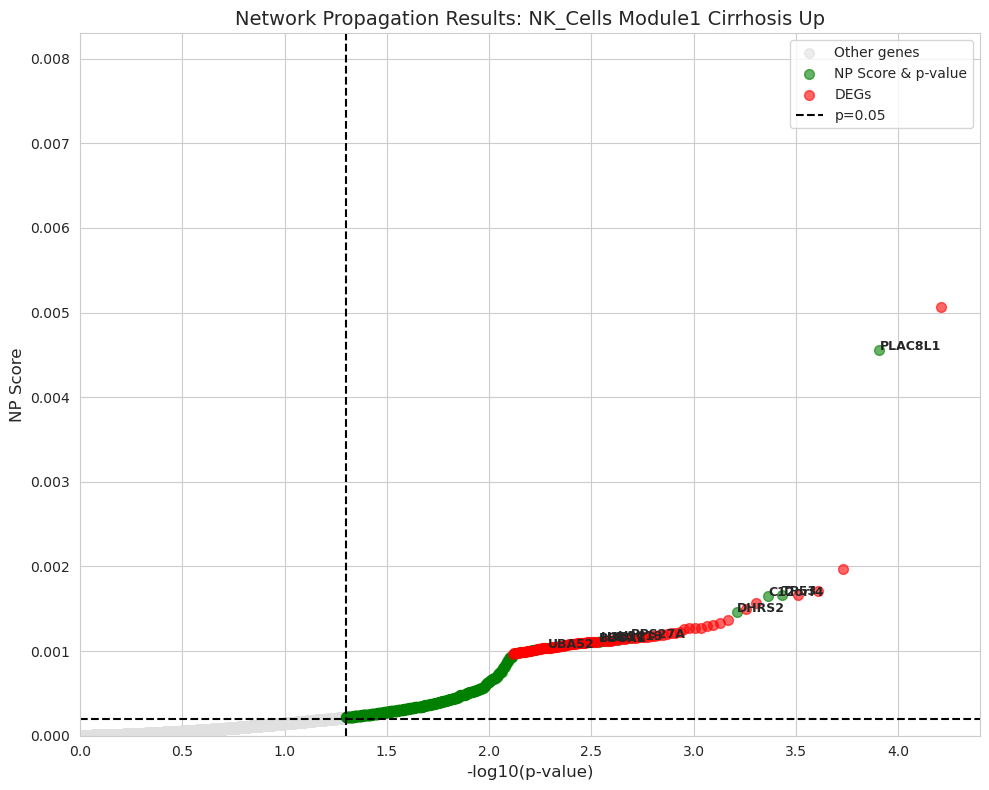

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000201
NP Score & p-value genes: 706

=== Novel Candidate Genes (706) ===
     Gene  NP_Score  P_value  Rank
  PLAC8L1  0.004554 0.000123     2
     TP53  0.001666 0.000370     6
  C12orf4  0.001656 0.000432     7
    DHRS2  0.001458 0.000617    10
   RPS27A  0.001151 0.002037    33
    H3C13  0.001131 0.002346    38
      UBC  0.001120 0.002654    43
    H3C12  0.001116 0.002839    46
    BBOX1  0.001113 0.002901    47
    UBA52  0.001038 0.005185    84
   CTNNB1  0.001036 0.005308    86
     H4C6  0.001018 0.005987    97
   TFAP2A  0.001016 0.006049    98
   NDUFB7  0.001014 0.006111    99
   ZFC3H1  0.001009 0.006172   100
    NDEL1  0.001005 0.006358   103
    EP300  0.000989 0.006851   111
      ERH  0.000985 0.007037   114
   PAPSS2  0.000973 0.007469   121
     GGA1  0.000970 0.007592   123
    H3-3B  0.000936 0.007716   125
  PPP1R21  0.000933 0.007777   126
    TAGAP  0.000931 0.007839   127
    HDAC1  0.000929 0.

In [10]:
df = pd.read_csv('NK_Cells_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: NK_Cells Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")

## Endothelial_Cells

In [11]:
df = pd.read_csv('Endothelial_Cells_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

with open('../seed/Endothelial_Cells_Module1_Cirrhosis_Up_511genes.txt', 'r') as f:
    seed_genes = set([line.strip() for line in f if line.strip()])

df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

df.to_csv('Endothelial_Cells_NP_Final_Results_top.csv', index=False)

print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 480 / 511

Top 20 Genes:
   Gene  NP_Score is_Seed  Rank  P_value
   TP53  0.001868      No     1 0.000062
 CTNNB1  0.001410     Yes     2 0.000123
  CDC42  0.001150      No     3 0.000185
  H3C13  0.001139      No     4 0.000247
  H3C12  0.001102      No     5 0.000309
FAM172A  0.001096     Yes     6 0.000370
  USP32  0.001096     Yes     7 0.000432
 ZNF407  0.001096     Yes     8 0.000494
 HP1BP3  0.001096     Yes     9 0.000556
 RPS27A  0.001051      No    10 0.000617
   EGFR  0.001048      No    11 0.000679
  EP300  0.001044      No    12 0.000741
  HDAC1  0.001020      No    13 0.000802
   H4C6  0.001004      No    14 0.000864
 ZNF236  0.000987      No    15 0.000926
  TTC9B  0.000987      No    16 0.000988
PLAC8L1  0.000987      No    17 0.001049
    UBC  0.000957      No    18 0.001111
   AKT1  0.000942      No    19 0.001173
  UBA52  0.000941      No    20 0.001234


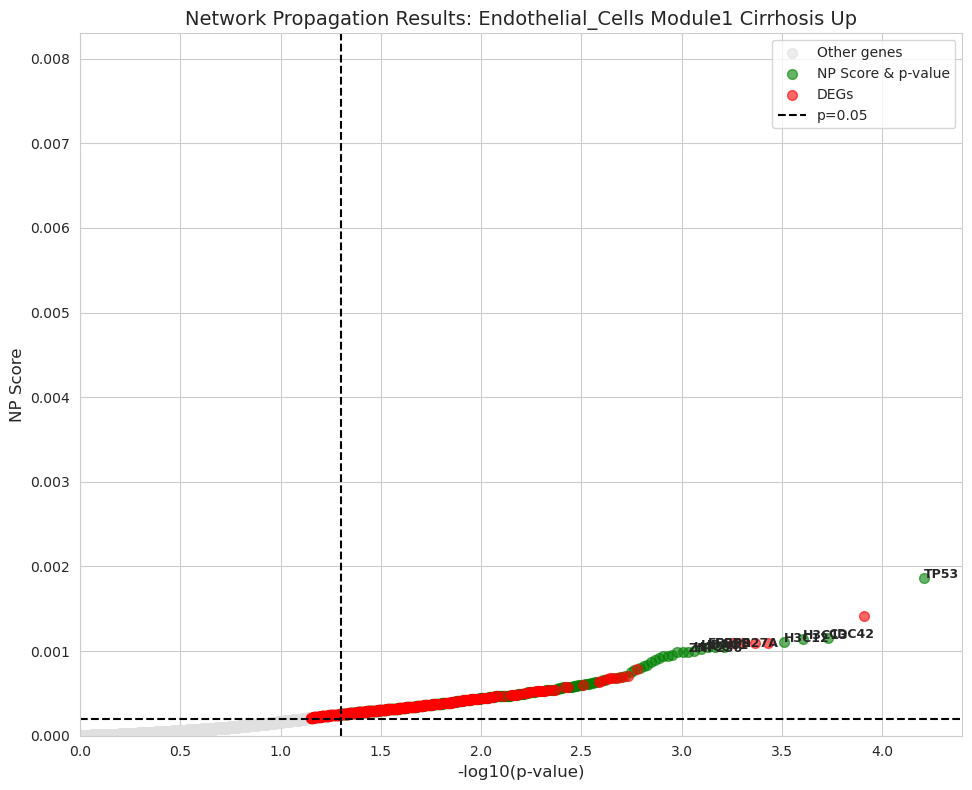

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000195
NP Score & p-value genes: 462

=== Novel Candidate Genes (462) ===
     Gene  NP_Score  P_value  Rank
     TP53  0.001868 0.000062     1
    CDC42  0.001150 0.000185     3
    H3C13  0.001139 0.000247     4
    H3C12  0.001102 0.000309     5
   RPS27A  0.001051 0.000617    10
     EGFR  0.001048 0.000679    11
    EP300  0.001044 0.000741    12
    HDAC1  0.001020 0.000802    13
     H4C6  0.001004 0.000864    14
   ZNF236  0.000987 0.000926    15
    TTC9B  0.000987 0.000988    16
  PLAC8L1  0.000987 0.001049    17
      UBC  0.000957 0.001111    18
     AKT1  0.000942 0.001173    19
    UBA52  0.000941 0.001234    20
     ACTB  0.000922 0.001296    21
    H3-3B  0.000897 0.001358    22
      SRC  0.000873 0.001420    23
     RHOA  0.000837 0.001481    24
    BRCA1  0.000825 0.001543    25
      MYC  0.000799 0.001605    26
     H3-4  0.000780 0.001728    28
 HSP90AA1  0.000756 0.001790    29
    HDAC2  0.000707 0.

In [12]:
df = pd.read_csv('Endothelial_Cells_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: Endothelial_Cells Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")

## Plasma_Cells

In [13]:
df = pd.read_csv('Plasma_Cells_NP_Result.txt', sep='\t', names=['Gene', 'NP_Score'])

with open('../seed/Plasma_Cells_Module1_Cirrhosis_Up_18genes.txt', 'r') as f:
    seed_genes = set([line.strip() for line in f if line.strip()])

df['is_Seed'] = df['Gene'].apply(lambda x: 'Yes' if x in seed_genes else 'No')
df = df.sort_values(by='NP_Score', ascending=False).reset_index(drop=True)
df['Rank'] = np.arange(1, len(df) + 1)
df['P_value'] = df['Rank'] / len(df)

df.to_csv('Plasma_Cells_NP_Final_Results_top.csv', index=False)

print(f"Total Genes in Network: {len(df)}")
print(f"Seed Genes found in network: {df['is_Seed'].value_counts().get('Yes', 0)} / {len(seed_genes)}")
print(f"\nTop 20 Genes:")
print(df.head(20).to_string(index=False))

Total Genes in Network: 16201
Seed Genes found in network: 16 / 18

Top 20 Genes:
   Gene  NP_Score is_Seed  Rank  P_value
    ALB  0.007520     Yes     1 0.000062
SEPTIN2  0.007270     Yes     2 0.000123
     C3  0.007218     Yes     3 0.000185
  APOA1  0.007218     Yes     4 0.000247
HSP90B1  0.007111     Yes     5 0.000309
   XBP1  0.006959     Yes     6 0.000370
  SEL1L  0.006876     Yes     7 0.000432
   PSAP  0.006870     Yes     8 0.000494
    A2M  0.006829     Yes     9 0.000556
  DAPK1  0.006708     Yes    10 0.000617
   PAK2  0.006540     Yes    11 0.000679
   POGZ  0.006520     Yes    12 0.000741
  KAT6A  0.006456     Yes    13 0.000802
    SON  0.006424     Yes    14 0.000864
  KLF12  0.006414     Yes    15 0.000926
   RERE  0.006396     Yes    16 0.000988
 TFAP2A  0.006203      No    17 0.001049
  EP300  0.002116      No    18 0.001111
   TP53  0.002094      No    19 0.001173
  HDAC1  0.001725      No    20 0.001234


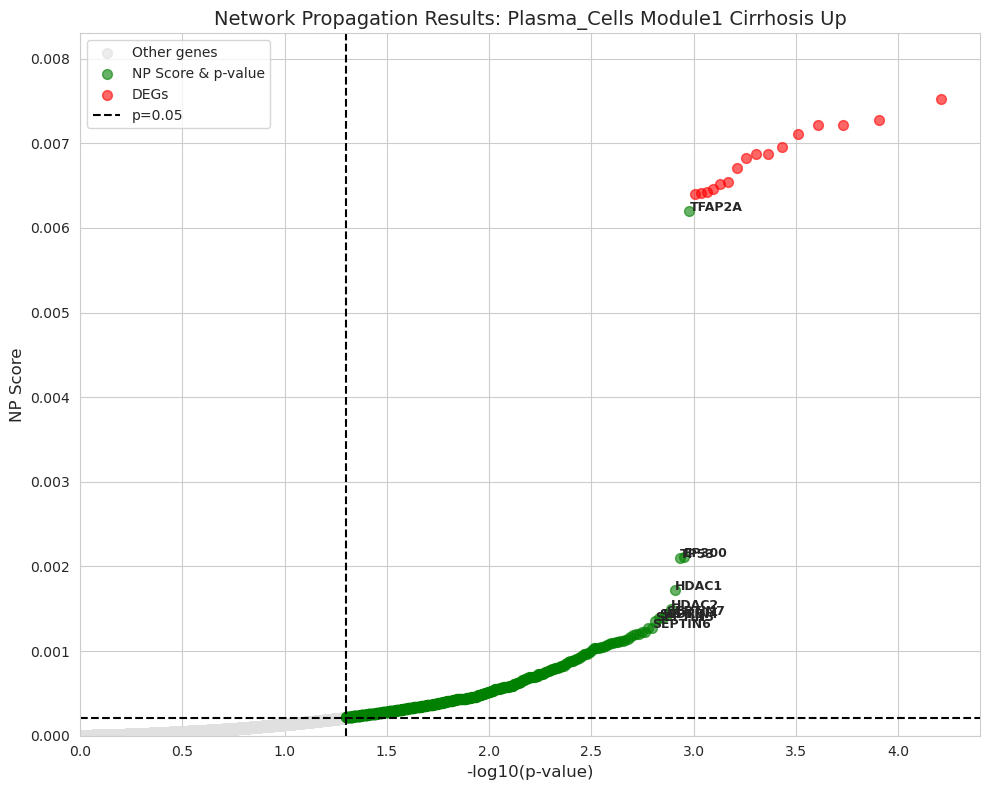

Total Genes in Network: 16201
SCORE_CUTOFF (non-seed top 5%): 0.000213
NP Score & p-value genes: 794

=== Novel Candidate Genes (794) ===
          Gene  NP_Score  P_value  Rank
        TFAP2A  0.006203 0.001049    17
         EP300  0.002116 0.001111    18
          TP53  0.002094 0.001173    19
         HDAC1  0.001725 0.001234    20
         HDAC2  0.001501 0.001296    21
       SEPTIN7  0.001429 0.001358    22
          WDR5  0.001392 0.001420    23
       SEPTIN4  0.001391 0.001481    24
       SEPTIN5  0.001361 0.001543    25
       SEPTIN6  0.001278 0.001605    26
       SEPTIN9  0.001273 0.001667    27
       SEPTIN1  0.001231 0.001728    28
       SEPTIN3  0.001220 0.001790    29
       SEPTIN8  0.001199 0.001852    30
      SEPTIN11  0.001199 0.001913    31
      SEPTIN10  0.001187 0.001975    32
          APOE  0.001171 0.002037    33
          RARB  0.001148 0.002099    34
          EGFR  0.001130 0.002160    35
         EHMT2  0.001115 0.002222    36
         H3C13  0.0011

In [14]:
df = pd.read_csv('Plasma_Cells_NP_Final_Results_top.csv')
df['log_p'] = -np.log10(df['P_value'] + 1e-10)

non_seed = df[df['is_Seed'] == 'No']
SCORE_CUTOFF = non_seed['NP_Score'].quantile(0.95)

color_palette = {'DEGs': 'red', 'NP Score & p-value': 'green', 'Other genes': '#e0e0e0'}
df['Category'] = 'Other genes'
df.loc[(df['P_value'] < 0.05) & (df['NP_Score'] >= SCORE_CUTOFF), 'Category'] = 'NP Score & p-value'
df.loc[df['is_Seed'] == 'Yes', 'Category'] = 'DEGs'

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
for cat in ['Other genes', 'NP Score & p-value', 'DEGs']:
    sub = df[df['Category'] == cat]
    plt.scatter(sub['log_p'], sub['NP_Score'], c=color_palette[cat],
                label=cat, alpha=0.6, s=50)

plt.axvline(x=-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
plt.axhline(y=SCORE_CUTOFF, color='black', linestyle='--')

top_non_seed = df[df['is_Seed'] == 'No'].nlargest(10, 'NP_Score')
for _, row in top_non_seed.iterrows():
    plt.text(row['log_p'], row['NP_Score'], row['Gene'], fontsize=9, fontweight='bold')

plt.title('Network Propagation Results: Plasma_Cells Module1 Cirrhosis Up', fontsize=14)
plt.xlabel('-log10(p-value)', fontsize=12)
plt.ylabel('NP Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xlim(0, 4.4)
plt.ylim(0, 0.0083)
plt.show()

# Summary
novel_candidates = df[df['Category'] == 'NP Score & p-value']

print(f"Total Genes in Network: {len(df)}")
print(f"SCORE_CUTOFF (non-seed top 5%): {SCORE_CUTOFF:.6f}")
print(f"NP Score & p-value genes: {len(novel_candidates)}")
print(f"\n=== Novel Candidate Genes ({len(novel_candidates)}) ===")
if len(novel_candidates) > 0:
    print(novel_candidates[['Gene', 'NP_Score', 'P_value', 'Rank']].to_string(index=False))
else:
    print("No novel candidate genes found.")